# Calculation of CDW from aarian's code

data needed to load 

- temp 
- salinity 

pre proccessing: 
 - depth, lat and lon and annual means
 - regrid to a consistent 1x1 gr

calculation of CDW 
- only consider ocean coloumns where the seaflorr is deeper than 1500m
- find winter water between 40-500m
- Then define CDW as the warmest temperature below that WW minimum
- 


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import os, glob, re
import pandas as pd
import datetime
import xesmf as xe

import warnings
warnings.filterwarnings('ignore')


In [2]:
def relabel_sort(SST):
    # rename to lon/lat depending on coordinate names
    rename_dict = {}
    if 'xu_ocean' in SST.dims and 'yu_ocean' in SST.dims:
        rename_dict = {'xu_ocean': 'lon', 'yu_ocean': 'lat'}
    elif 'xt_ocean' in SST.dims and 'yt_ocean' in SST.dims:
        rename_dict = {'xt_ocean': 'lon', 'yt_ocean': 'lat'}

    sorted_sst = SST.rename(rename_dict)

    # shift longitude from [-180,180] to [0,360]
    sorted_sst['lon'] = (sorted_sst['lon'] + 360) % 360

    # sort by longitude for consistent ordering
    sorted_sst = sorted_sst.sortby('lon')
    sorted_sst = sorted_sst.sel(lat = slice(-20,20)).sel(lon = slice(110,300))

    return sorted_sst

In [6]:
def find_trend_values(dt):

    #Input: xarray array with time, lat, lon coordinates and a variable to calculate the trend
    #Output: xarray array with the trend values for each grid point
    
    time, lat, lon = dt['time'].values, dt['lat'].values, dt['lon'].values
    sst_reshaped = dt.values.reshape(len(time), -1)
    degree = 1

    gradient_values = np.empty_like(sst_reshaped[0])
    for i in range(len(sst_reshaped[0])):
        y = sst_reshaped[:, i]
        coefficients = np.polyfit(np.arange(len(time)), y, degree)
        gradient_values[i] = coefficients[-2]  # Coefficient for x term (slope)

    gradient_values = gradient_values.reshape(lat.shape[0], lon.shape[0])
    gradient_da = xr.DataArray(gradient_values, coords={'lat': lat, 'lon': lon}, dims=['lat', 'lon'])
    return gradient_da 

In [2]:
def find_files(model, version, scenario):
    BASE      = "/g/data/oi10/replicas/CMIP6/ScenarioMIP"
    # INSTITUTE = ""
    MODEL = model
    SCENARIO  =scenario    
    MEMBER_GLOB = "r1i1p1f1" 
    VERSION = version
    
    pattern = str(
        Path(BASE) / "*" / MODEL / SCENARIO / MEMBER_GLOB / "Omon" / "thetao" / "gn" / VERSION / "*"
    )
    print("Searching pattern:\n", pattern)
    
    matches = []
    for p in glob.iglob(pattern):
        if os.path.isfile(p):
            matches.append(os.path.realpath(p))
    
    matches = sorted(matches)
    return matches

In [3]:
# regrid - make one for canESM and apply to both ssp126 and ssp585 - save gridded product 

def make_regridder(ds_native):
    
    # Create the target grid (1°x1° global)
    ds_out = xr.Dataset({
        'lat': (['lat'],  np.arange(-89.5, 90.5, 1.0)),
        'lon': (['lon'],  np.arange(0.5, 360.5, 1.0)),
    })
    
    # Create regridder (uses bilinear interpolation by default)
    regridder = xe.Regridder(ds_native, ds_out, method='bilinear', periodic=True)
    
    # Apply regridding to a variable, e.g., sea surface temperature
    # regridder = regridder(ds_native)
    
    return regridder



## canESM5

In [16]:
matches = find_files("CanESM5","v20190429","ssp126") # find files
# load datasets - for canESM5 slice at 2100 so that when interpolate is done later on there's no nans
CanESM5_glob_ssp126 = xr.open_mfdataset(matches, combine='by_coords').sel(lev = slice(0,2100))
# CanESM5_glob_ssp126

Searching pattern:
 /g/data/oi10/replicas/CMIP6/ScenarioMIP/*/CanESM5/ssp126/r1i1p1f1/Omon/thetao/gn/v20190429/*


/jobfs/161050317.gadi-pbs/ipykernel_89479/2128963122.py:3: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  CanESM5_glob_ssp126 = xr.open_mfdataset(matches, combine='by_coords').sel(lev = slice(0,2100))
/jobfs/161050317.gadi-pbs/ipykernel_89479/2128963122.py:3: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  CanESM5_glob_ssp126 = xr.open_mfdataset(matches, combine='by_coords').sel(lev = slice(0,2100))
/jobfs/161050317.gadi-pbs/ipykernel_89479/2128963122.py:3: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.

In [17]:
can_regridder = make_regridder(CanESM5_glob_ssp126.thetao)
canESM5_ssp126_gr =can_regridder(CanESM5_glob_ssp126.thetao)


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.02/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:310: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 8.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (145, 109).
  result_var = func(*data_vars)


In [22]:
canESM5_ssp126_gr.to_netcdf('/g/data/e14/ic0706/CMIP/CanESM5/ssp126/canESM5_ssp126_201512_230012_gr.nc')

In [19]:
matches = find_files("CanESM5","v20190429","ssp585")
CanESM5_glob_ssp585 = xr.open_mfdataset(matches, combine='by_coords').sel(lev = slice(0,2100))
print('opened datasets')

Searching pattern:
 /g/data/oi10/replicas/CMIP6/ScenarioMIP/*/CanESM5/ssp585/r1i1p1f1/Omon/thetao/gn/v20190429/*
opened datasets


In [ ]:
canESM5_ssp585_gr =can_regridder(CanESM5_glob_ssp585.thetao)
print('regridded')
canESM5_ssp585_gr.to_netcdf('/g/data/e14/ic0706/CMIP/CanESM5/ssp585/canESM5_ssp585_201512_230012_gr.nc')
print('saved')

regridded


## IPSL-CM6A-LR

In [4]:
matches = find_files("IPSL-CM6A-LR","v*","ssp126")
IPSL_glob_ssp126 = xr.open_mfdataset(matches, combine='by_coords',use_cftime=True).rename({'olevel':'lev'}).sel(lev = slice(0,2000))

Searching pattern:
 /g/data/oi10/replicas/CMIP6/ScenarioMIP/*/IPSL-CM6A-LR/ssp126/r1i1p1f1/Omon/thetao/gn/v*/*


In [5]:
matches = find_files("IPSL-CM6A-LR","v*","ssp585")
IPSL_glob_ssp585 = xr.open_mfdataset(matches, combine='by_coords',use_cftime=True).rename({'olevel':'lev'}).sel(lev = slice(0,2000))
print('opened datasets')

Searching pattern:
 /g/data/oi10/replicas/CMIP6/ScenarioMIP/*/IPSL-CM6A-LR/ssp585/r1i1p1f1/Omon/thetao/gn/v*/*
opened datasets


In [8]:
IPSL_glob_ssp126.thetao


<xarray.DataArray 'thetao' (time: 3432, lev: 54, y: 332, x: 362)> Size: 89GB
dask.array<getitem, shape=(3432, 54, 332, 362), dtype=float32, chunksize=(1, 54, 332, 362), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 27kB 2015-01-16 12:00:00 ... 2300-12-16 12:00:00
  * lev      (lev) float32 216B 0.5058 1.556 2.668 ... 1.796e+03 1.945e+03
    nav_lat  (y, x) float32 481kB dask.array<chunksize=(332, 362), meta=np.ndarray>
    nav_lon  (y, x) float32 481kB dask.array<chunksize=(332, 362), meta=np.ndarray>
Dimensions without coordinates: y, x
Attributes:
    standard_name:       sea_water_potential_temperature
    long_name:           Sea Water Potential Temperature
    units:               degC
    online_operation:    average
    cell_methods:        area: mean where sea time: mean
    interval_operation:  2700 s
    interval_write:      1 month
    cell_measures:       area: areacello volume: volcello
    description:         Diagnostic should be contributed even for models usi...
    history:             none

In [6]:
# find regridder 
ipsl_regridder = make_regridder(IPSL_glob_ssp126.thetao)


ValueError: ESMC_FieldRegridStore failed with rc = 506. Please check the log files (named "*ESMF_LogFile").

In [ ]:
IPSL_ssp126_gr =ipsl_regridder(IPSL_glob_ssp126.thetao)
print('regridded')
IPSL_ssp126_gr.to_netcdf('/g/data/e14/ic0706/CMIP/IPSL-CM6A-LR/ssp126/IPSL-CM6A-LR_ssp126_201512-230012_gr.nc')
print('saved')

In [ ]:
IPSL_ssp585_gr =ipsl_regridder(IPSL_glob_ssp585.thetao)
print('regridded')
IPSL_ssp585_gr.to_netcdf('/g/data/e14/ic0706/CMIP/IPSL-CM6A-LR/ssp585/IPSL-CM6A-LR_ssp585_201512-230012_gr.nc')
print('saved')

## MRI-ESM2-0

In [9]:
matches = find_files("MRI-ESM2-0","v20210329","ssp126")
MRI_glob_ssp126 = xr.open_mfdataset(matches, combine='by_coords',use_cftime=True)
print('opened dataset')

Searching pattern:
 /g/data/oi10/replicas/CMIP6/ScenarioMIP/*/MRI-ESM2-0/ssp126/r1i1p1f1/Omon/thetao/gn/v20210329/*
opened dataset


In [10]:
matches = find_files("MRI-ESM2-0","v*","ssp585")
MRI_glob_ssp585 = xr.open_mfdataset(matches, combine='by_coords',use_cftime=True)
print('opened datasets')


Searching pattern:
 /g/data/oi10/replicas/CMIP6/ScenarioMIP/*/MRI-ESM2-0/ssp585/r1i1p1f1/Omon/thetao/gn/v*/*
opened datasets


In [11]:
# calc regridder 
mri_regridder = make_regridder(MRI_glob_ssp126.thetao) 


In [ ]:
MRI_ssp126_gr =mri_regridder(MRI_glob_ssp126.thetao)
print('regridded')
MRI_ssp126_gr.to_netcdf('/g/data/e14/ic0706/CMIP/MRI-ESM2-0/ssp126/MRI-ESM2-0_ssp126_201512-230012_gr.nc')
print('saved')

regridded


In [ ]:
MRI_ssp585_gr =mri_regridder(MRI_glob_ssp585.thetao)
print('regridded')
MRI_ssp585_gr.to_netcdf('/g/data/e14/ic0706/CMIP/MRI-ESM2-0/ssp585/MRI-ESM2-0_ssp585_201512-230012_gr.nc')
print('saved')

## CESM2-WACCM 

this dumb as fuck model uses cm for depth

In [ ]:
matches = find_files("CESM2-WACCM","v*","ssp126")
CESM2_glob_ssp126 = xr.open_mfdataset(matches, combine='by_coords',use_cftime=True)
# this model actually uses cm as units for depth -- unreal, convert to m like normal
CESM2_glob_ssp126['lev'] = CESM2_glob_ssp126['lev'] / 100.0
CESM2_glob_ssp126.lev.attrs = {
    'axis': 'Z',
    'bounds': 'lev_bnds',
    'positive': 'down',
    'standard_name': 'olevel',
    'title': 'ocean model level',
    'type': 'double',
    'units': 'm',
}
CESM2_glob_ssp126 = CESM2_glob_ssp126.sel(lev = slice(0,2200))
print('opened dataset')


In [ ]:
matches = find_files("CESM2-WACCM","v*","ssp585")
CESM2_glob_ssp585 = xr.open_mfdataset(matches, combine='by_coords',use_cftime=True)
# convert to m 
CESM2_glob_ssp585['lev'] = CESM2_glob_ssp585['lev'] / 100.0
CESM2_glob_ssp585.lev.attrs = {
    'axis': 'Z',
    'bounds': 'lev_bnds',
    'positive': 'down',
    'standard_name': 'olevel',
    'title': 'ocean model level',
    'type': 'double',
    'units': 'm',
}
CESM2_glob_ssp585 = CESM2_glob_ssp585.sel(lev = slice(0,2200))
print('opened dataset')


In [ ]:
# calc regridder 
cesm2_regridder = make_regridder(CESM2_glob_ssp126.thetao)


In [ ]:
cesm2_ssp126_gr =cesm2_regridder(CESM2_glob_ssp126.thetao)
print('regridded')
cesm2_ssp126_gr.to_netcdf('/g/data/e14/ic0706/CMIP/CESM2-WACCM/ssp126/CESM2-WACCM_ssp126_201512-230012_gr.nc')
print('saved')

In [ ]:
cesm2_ssp585_gr =cesm2_regridder(CESM2_glob_ssp585.thetao)
print('regridded')
cesm2_ssp585_gr.to_netcdf('/g/data/e14/ic0706/CMIP/CESM2-WACCM/ssp585/CESM2-WACCM_ssp585_201512-230012_gr.nc')
print('saved')

##  UKESM1-0-LL

In [ ]:
# file list -  /g/data/e14/ic0706
# code to look for models upto 2300
# g/data/oi10/replicas/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp126/r4i1p1f2/Omon/thetao/gn/v20211202/thetao_Omon_UKESM1-0-LL_ssp126_r4i1p1f2_gn_225001-229912.nc
# === Params  ===
BASE      = "/g/data/oi10/replicas/CMIP6/ScenarioMIP"
# INSTITUTE = ""
MODEL = "UKESM1-0-LL"
SCENARIO  = "ssp126"    
MEMBER_GLOB = "r4i1p1f2" 
VERSION = "v20211202"
TAIL      =  "*.nc"   # 230012 - check model goes to 2300
SAVE_TXT  = ""  # e.g., "/g/data/oi10/ic0706/matches.txt" to save; leave "" to skip
# ===========================

pattern = str(
    Path(BASE) / "*" / MODEL / SCENARIO / MEMBER_GLOB / "Omon" / "thetao" / "gn" / VERSION / f"*{TAIL}"
)
print("Searching pattern:\n", pattern)

matches = []
for p in glob.iglob(pattern):
    if os.path.isfile(p):
        matches.append(os.path.realpath(p))



folder = Path("/g/data/e14/ic0706/ScenarioMIP_SO/UKESM1-0-LL/ssp126")
pattern = "thetao_Omon_UKESM1-0-LL_ssp126_*_gn_*.nc"

# Collect files and add without duplicates
new_files = sorted(str(p) for p in folder.glob(pattern))
seen = set(matches)
matches.extend([f for f in new_files if f not in seen])

matches = sorted(matches)

# print(f"\nFound {len(matches)} file(s).")
# for m in matches:
#     print(m)
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

UKESM_glob_ssp126 = xr.open_mfdataset(matches, combine='by_coords',decode_times = time_coder).sel(lev = slice(0,2000))
print('opened datasets')

In [ ]:
# file list - part in /g/data/oi10/ part in /g/data/e14/ic0706

# file list - part in /g/data/oi10/ part in /g/data/e14/ic0706
# code to look for models upto 2300
# g/data/oi10/replicas/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp126/r4i1p1f2/Omon/thetao/gn/v20211202/thetao_Omon_UKESM1-0-LL_ssp126_r4i1p1f2_gn_225001-229912.nc
folder = Path("/g/data/e14/ic0706/ScenarioMIP_SO/UKESM1-0-LL/ssp585")
pattern = "thetao_Omon_UKESM1-0-LL_ssp585_*_gn_*.nc"

# Collect files and add without duplicates
new_files = sorted(str(p) for p in folder.glob(pattern))
matches = sorted(new_files)

print(f"\nFound {len(matches)} file(s).")
for m in matches:
    print(m)

time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
UKESM_glob_ssp585 = xr.open_mfdataset(matches, combine='by_coords',decode_times = time_coder).sel(lev = slice(0,2000))
print('opened datasets')

In [ ]:
# calc regridder 
ukesm_regridder = make_regridder(UKESM_glob_ssp126.thetao)


In [ ]:
ukesm_ssp126_gr =ukesm_regridder(UKESM_glob_ssp126.thetao)
print('regridded')
ukesm_ssp126_gr.to_netcdf('/g/data/e14/ic0706/CMIP/UKESM1-0-LL/ssp126/UKESM1-0-LL_ssp126_201512-230012_gr.nc')
print('saved')

In [ ]:
ukesm_ssp585_gr =ukesm_regridder(UKESM_glob_ssp585.thetao)
print('regridded')
ukesm_ssp585_gr.to_netcdf('/g/data/e14/ic0706/CMIP/UKESM1-0-LL/ssp585/UKESM1-0-LL_ssp585_201512-230012_gr.nc')
print('saved')

In [3]:
t = xr.open_dataset('/g/data/e14/ic0706/CMIP/CanESM5/ssp585/canESM5_ssp585_201512_230012_gr.nc')
t

<xarray.Dataset> Size: 27GB
Dimensions:                        (time: 3432, lev: 30, lat: 180, lon: 360)
Coordinates:
  * time                           (time) object 27kB 2015-01-16 12:00:00 ......
  * lev                            (lev) float64 240B 3.047 9.454 ... 2.054e+03
  * lat                            (lat) float64 1kB -89.5 -88.5 ... 88.5 89.5
  * lon                            (lon) float64 3kB 0.5 1.5 2.5 ... 358.5 359.5
Data variables:
    __xarray_dataarray_variable__  (time, lev, lat, lon) float32 27GB ...

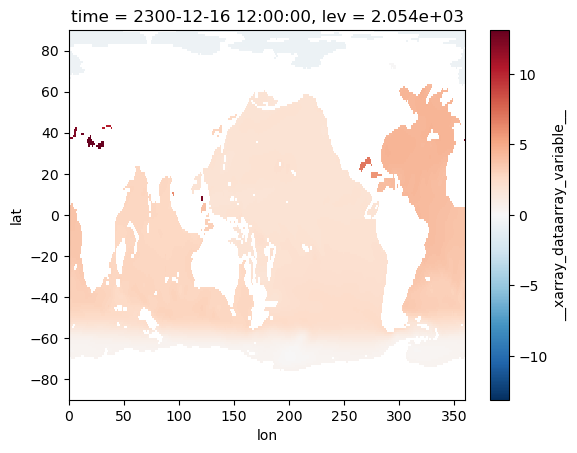

In [6]:
t.__xarray_dataarray_variable__.isel(time= -1, lev=-1).plot()